<a href="https://colab.research.google.com/github/Md-Golam-Raiyhan/INSE-6450-Milestone-1/blob/main/notebooks/data_exploration2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Md-Golam-Raiyhan/INSE-6450-Milestone-1.git


Cloning into 'INSE-6450-Milestone-1'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 128 (delta 55), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (128/128), 208.69 KiB | 1.48 MiB/s, done.
Resolving deltas: 100% (55/55), done.


In [2]:
%cd INSE-6450-Milestone-1


/content/INSE-6450-Milestone-1


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make output folder
os.makedirs("outputs", exist_ok=True)

print("✅ Setup complete")
print("Current working directory:", os.getcwd())

✅ Setup complete
Current working directory: /content/INSE-6450-Milestone-1


In [4]:
os.makedirs("data", exist_ok=True)

# Move CSVs into data/ if they are in the root directory
for f in ["pantry.csv", "consumption_log.csv", "recipes.csv", "user_profile.csv"]:
    if os.path.exists(f):
        os.rename(f, os.path.join("data", f))

!ls data


consumption_log.csv  pantry.csv  recipes.csv  user_profile.csv


In [5]:
pantry = pd.read_csv("data/pantry.csv")
consumption = pd.read_csv("data/consumption_log.csv")
recipes = pd.read_csv("data/recipes.csv")
user = pd.read_csv("data/user_profile.csv")

print("✅ Loaded datasets:")
print("pantry:", pantry.shape)
print("consumption_log:", consumption.shape)
print("recipes:", recipes.shape)
print("user_profile:", user.shape)


✅ Loaded datasets:
pantry: (15, 6)
consumption_log: (90, 4)
recipes: (10, 7)
user_profile: (1, 5)


In [6]:
def show_schema_and_examples(df, name, n=5):
    print(f"\n==================== {name.upper()} ====================")
    print("Shape:", df.shape)
    print("\nColumns & dtypes:")
    print(df.dtypes)
    print("\nExample rows:")
    display(df.head(n))

show_schema_and_examples(pantry, "pantry")
show_schema_and_examples(consumption, "consumption_log")
show_schema_and_examples(recipes, "recipes")
show_schema_and_examples(user, "user_profile")



==================== PANTRY ====================
Shape: (15, 6)

Columns & dtypes:
item_id        int64
item_name     object
category      object
unit          object
essential      int64
quantity     float64
dtype: object

Example rows:


,item_id,item_name,category,unit,essential,quantity
0,1,Rice,Grain,kg,1,5.0
1,2,Eggs,Dairy,piece,1,12.0
2,3,Milk,Dairy,liter,1,2.0
3,4,Chicken,Meat,kg,0,1.5
4,5,Onion,Vegetable,piece,1,6.0



==================== CONSUMPTION_LOG ====================
Shape: (90, 4)

Columns & dtypes:
week               int64
item_id            int64
quantity_used    float64
unit              object
dtype: object

Example rows:


,week,item_id,quantity_used,unit
0,1,1,0.97,kg
1,1,2,4.00,piece
2,1,3,1.18,liter
3,1,4,0.63,kg
4,1,5,1.00,piece



==================== RECIPES ====================
Shape: (10, 7)

Columns & dtypes:
recipe_id            int64
recipe_name         object
ingredients         object
cooking_time_min     int64
cost_level          object
diet                object
allergens           object
dtype: object

Example rows:


,recipe_id,recipe_name,ingredients,cooking_time_min,cost_level,diet,allergens
0,1,Vegetable Fried Rice,"Rice,Onion,Tomato,Spinach",25,low,veg,none
1,2,Chicken Fried Rice,"Rice,Chicken,Eggs,Onion",30,medium,non-veg,egg
2,3,Egg Curry,"Eggs,Onion,Tomato",20,low,non-veg,egg
3,4,Lentil Soup,"Lentils,Onion,Tomato",35,low,veg,none
4,5,Pasta with Tomato,"Pasta,Tomato,Onion,Cheese",25,medium,veg,milk



==================== USER_PROFILE ====================
Shape: (1, 5)

Columns & dtypes:
user_id           int64
diet             object
allergies        object
max_time_min      int64
weekly_budget    object
dtype: object

Example rows:


,user_id,diet,allergies,max_time_min,weekly_budget
0,1,non-veg,egg,30,low


In [7]:
def missing_summary(df, name):
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    summary = pd.DataFrame({"missing_count": miss, "missing_percent": miss_pct})
    print(f"\nMissingness Summary: {name}")
    display(summary)

missing_summary(pantry, "pantry")
missing_summary(consumption, "consumption_log")
missing_summary(recipes, "recipes")
missing_summary(user, "user_profile")



Missingness Summary: pantry


,missing_count,missing_percent
item_id,0,0.0
item_name,0,0.0
category,0,0.0
unit,0,0.0
essential,0,0.0
quantity,0,0.0



Missingness Summary: consumption_log


,missing_count,missing_percent
week,0,0.0
item_id,0,0.0
quantity_used,0,0.0
unit,0,0.0



Missingness Summary: recipes


,missing_count,missing_percent
recipe_id,0,0.0
recipe_name,0,0.0
ingredients,0,0.0
cooking_time_min,0,0.0
cost_level,0,0.0
diet,0,0.0
allergens,0,0.0



Missingness Summary: user_profile


,missing_count,missing_percent
user_id,0,0.0
diet,0,0.0
allergies,0,0.0
max_time_min,0,0.0
weekly_budget,0,0.0


In [8]:
def numeric_summary(df, name):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"\nNumeric Summary Stats: {name}")
    if len(num_cols) == 0:
        print("No numeric columns found.")
        return
    display(df[num_cols].describe())

numeric_summary(pantry, "pantry")
numeric_summary(consumption, "consumption_log")
numeric_summary(recipes, "recipes")
numeric_summary(user, "user_profile")



Numeric Summary Stats: pantry


,item_id,essential,quantity
count,15.000000,15.000000,15.000000
mean,8.000000,0.466667,5.153333
std,4.472136,0.516398,3.794143
min,1.000000,0.000000,0.800000
25%,4.500000,0.000000,2.000000
50%,8.000000,0.000000,5.000000
75%,11.500000,1.000000,8.000000
max,15.000000,1.000000,12.000000



Numeric Summary Stats: consumption_log


,week,item_id,quantity_used
count,90.000000,90.000000,90.000000
mean,3.500000,8.000000,2.383667
std,1.717393,4.344698,2.235920
min,1.000000,1.000000,0.000000
25%,2.000000,4.000000,0.615000
50%,3.500000,8.000000,1.165000
75%,5.000000,12.000000,4.000000
max,6.000000,15.000000,9.000000



Numeric Summary Stats: recipes


,recipe_id,cooking_time_min
count,10.00000,10.000000
mean,5.50000,24.000000
std,3.02765,10.219806
min,1.00000,10.000000
25%,3.25000,16.250000
50%,5.50000,25.000000
75%,7.75000,30.000000
max,10.00000,40.000000



Numeric Summary Stats: user_profile


,user_id,max_time_min
count,1.0,1.0
mean,1.0,30.0
std,NaN,NaN
min,1.0,30.0
25%,1.0,30.0
50%,1.0,30.0
75%,1.0,30.0
max,1.0,30.0


In [9]:
def duplicate_check(df, name):
    dup_count = df.duplicated().sum()
    print(f"\nDuplicate Check: {name}")
    print("Duplicate rows:", dup_count)
    if dup_count > 0:
        display(df[df.duplicated()].head(10))

duplicate_check(pantry, "pantry")
duplicate_check(consumption, "consumption_log")
duplicate_check(recipes, "recipes")
duplicate_check(user, "user_profile")



Duplicate Check: pantry
Duplicate rows: 0

Duplicate Check: consumption_log
Duplicate rows: 0

Duplicate Check: recipes
Duplicate rows: 0

Duplicate Check: user_profile
Duplicate rows: 0


In [10]:
def outlier_check_iqr(df, col, name):
    # Drop missing values
    x = df[col].dropna()
    if len(x) == 0:
        print(f"No data for outlier check in {name}.{col}")
        return

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    outliers = df[(df[col] < low) | (df[col] > high)]
    print(f"\nOutlier Check (IQR): {name}.{col}")
    print(f"Q1={q1:.3f}, Q3={q3:.3f}, IQR={iqr:.3f}, low={low:.3f}, high={high:.3f}")
    print("Outlier rows:", len(outliers))
    if len(outliers) > 0:
        display(outliers.head(10))

# Choose key numeric columns
if "quantity" in pantry.columns:
    outlier_check_iqr(pantry, "quantity", "pantry")

if "quantity_used" in consumption.columns:
    outlier_check_iqr(consumption, "quantity_used", "consumption_log")

if "cooking_time_min" in recipes.columns:
    outlier_check_iqr(recipes, "cooking_time_min", "recipes")



Outlier Check (IQR): pantry.quantity
Q1=2.000, Q3=8.000, IQR=6.000, low=-7.000, high=17.000
Outlier rows: 0

Outlier Check (IQR): consumption_log.quantity_used
Q1=0.615, Q3=4.000, IQR=3.385, low=-4.462, high=9.078
Outlier rows: 0

Outlier Check (IQR): recipes.cooking_time_min
Q1=16.250, Q3=30.000, IQR=13.750, low=-4.375, high=50.625
Outlier rows: 0


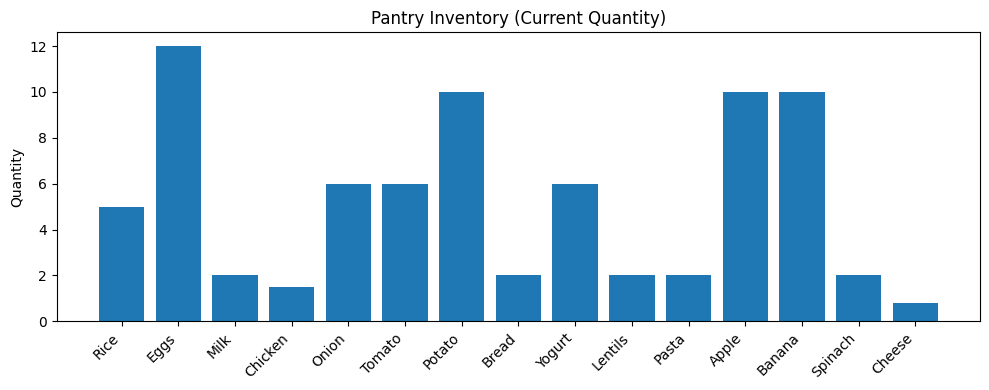

✅ Saved: outputs/pantry_inventory.png


In [11]:
plt.figure(figsize=(10,4))
plt.bar(pantry["item_name"], pantry["quantity"])
plt.xticks(rotation=45, ha="right")
plt.title("Pantry Inventory (Current Quantity)")
plt.ylabel("Quantity")
plt.tight_layout()
plt.savefig("outputs/pantry_inventory.png")
plt.show()

print("✅ Saved: outputs/pantry_inventory.png")


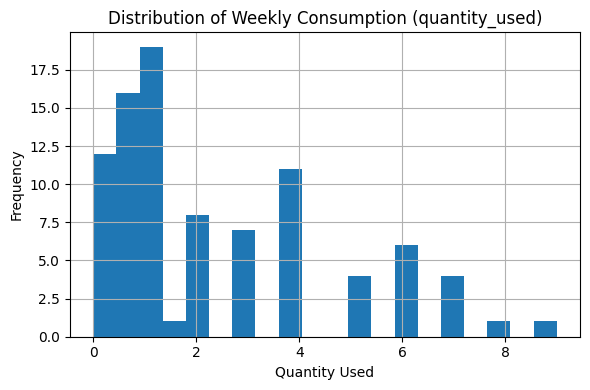

✅ Saved: outputs/consumption_hist.png


In [12]:
plt.figure(figsize=(6,4))
consumption["quantity_used"].hist(bins=20)
plt.title("Distribution of Weekly Consumption (quantity_used)")
plt.xlabel("Quantity Used")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/consumption_hist.png")
plt.show()

print("✅ Saved: outputs/consumption_hist.png")


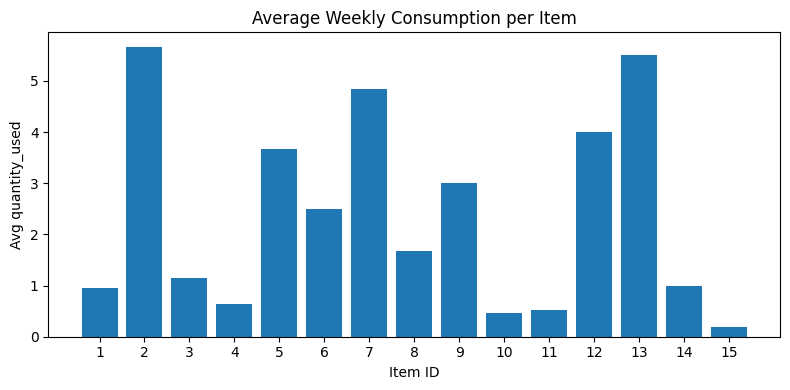

✅ Saved: outputs/avg_weekly_consumption_per_item.png


In [13]:
avg_use = consumption.groupby("item_id")["quantity_used"].mean().reset_index()

plt.figure(figsize=(8,4))
plt.bar(avg_use["item_id"].astype(str), avg_use["quantity_used"])
plt.title("Average Weekly Consumption per Item")
plt.xlabel("Item ID")
plt.ylabel("Avg quantity_used")
plt.tight_layout()
plt.savefig("outputs/avg_weekly_consumption_per_item.png")
plt.show()

print("✅ Saved: outputs/avg_weekly_consumption_per_item.png")


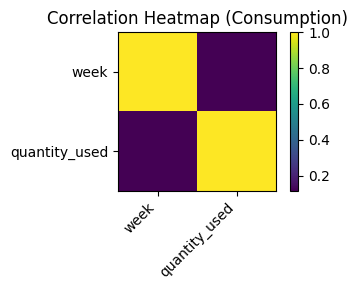

✅ Saved: outputs/consumption_corr_heatmap.png


In [14]:
# Combine a few numeric fields for correlation (example)
tmp = consumption[["week", "quantity_used"]].copy()
tmp = tmp.dropna()

if tmp.shape[1] >= 2:
    corr = tmp.corr()
    plt.figure(figsize=(4,3))
    plt.imshow(corr.values)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Heatmap (Consumption)")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig("outputs/consumption_corr_heatmap.png")
    plt.show()
    print("✅ Saved: outputs/consumption_corr_heatmap.png")
else:
    print("Not enough numeric columns for correlation heatmap.")


In [15]:
summary_rows = []

def add_summary(df, name):
    summary_rows.append({
        "dataset": name,
        "num_rows": df.shape[0],
        "num_cols": df.shape[1],
        "missing_total": int(df.isnull().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum())
    })

add_summary(pantry, "pantry")
add_summary(consumption, "consumption_log")
add_summary(recipes, "recipes")
add_summary(user, "user_profile")

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("outputs/data_exploration_summary.csv", index=False)

display(summary_df)
print("✅ Saved: outputs/data_exploration_summary.csv")


,dataset,num_rows,num_cols,missing_total,duplicate_rows
0,pantry,15,6,0,0
1,consumption_log,90,4,0,0
2,recipes,10,7,0,0
3,user_profile,1,5,0,0


✅ Saved: outputs/data_exploration_summary.csv


In [16]:
from google.colab import files
files.download("outputs/pantry_inventory.png")
files.download("outputs/consumption_hist.png")
files.download("outputs/avg_weekly_consumption_per_item.png")
files.download("outputs/data_exploration_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>